In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/data_labelled.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
irrelevant = ['User_ID']

In [5]:
df = df.drop(columns=irrelevant)

In [6]:
le = LabelEncoder()
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])

In [7]:
df.Stress_Level.value_counts()

Stress_Level
0    19950
2    15043
1    15007
Name: count, dtype: int64

In [8]:
X = df.drop('Stress_Level', axis=1)
y = df['Stress_Level']

In [9]:
X = pd.get_dummies(X, drop_first=True)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Gradient Boosting 

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [13]:
y_pred_gb = gb_model.predict(X_test_scaled)

In [14]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.3940666666666667
              precision    recall  f1-score   support

           0       0.40      0.96      0.56      5985
           1       0.25      0.02      0.03      4502
           2       0.32      0.02      0.05      4513

    accuracy                           0.39     15000
   macro avg       0.32      0.33      0.21     15000
weighted avg       0.33      0.39      0.25     15000



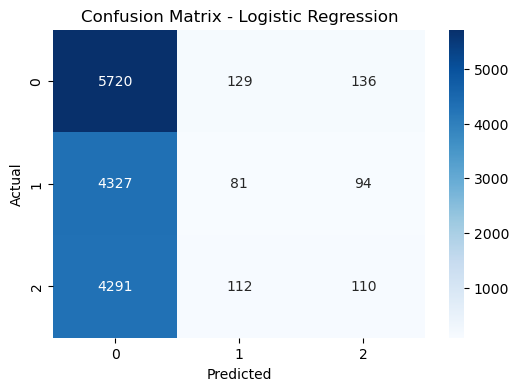

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [16]:
from sklearn.model_selection import cross_val_score
gb_scores = cross_val_score(
    gb_model, 
    X_train_scaled, 
    y_train, 
    cv=5)


print("GB CV Accuracy:", gb_scores.mean())

GB CV Accuracy: 0.39514285714285713
